In [1]:
from dotenv import load_dotenv
import os
# from os import getenv
load_dotenv()

True

In [2]:
# from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
# chat_llm=ChatGoogleGenerativeAI(model="gemini-1.5-flash")

In [4]:
from langchain_openai import ChatOpenAI

In [5]:
from pydantic import SecretStr

In [6]:
api_key=os.getenv("OPENROUTER_API_KEY")

In [31]:
llm_chat=ChatOpenAI(
    # model="nvidia/nemotron-nano-12b-v2-vl:free",
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(api_key),
)

In [32]:
response=llm_chat.invoke([HumanMessage(content="Hello, How are you?")])
print(response.content)

Hello! I'm doing well, thank you for asking. I don't have feelings, but I'm all set and ready to help you with whatever you need. 😊

How can I assist you today?


In [9]:
from typing_extensions import TypedDict
import operator

In [28]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [11]:
from typing import Annotated, List

In [12]:
class GraphState(TypedDict):
    message: Annotated[List[AnyMessage], operator.add] # inside one list all the message will be aappended
    # here 'message' is a key & 'Ann....' is a value

In [ ]:
# {
#     "message": [HumanMessage(content="Hi, this is Suman, Say hello in details.")]
# }

In [ ]:
# ["hi"]

In [ ]:
# ["hi","how are you"]

In [13]:
# whatever input comes to thius node it's going to generate a response regarding that input
def llm_call(state: GraphState) -> dict: # passing input in the form of state
    """Call the LLM using conversion message and append AI response"""
    response=llm_chat.invoke(state["message"]) # state omly are going to collect the input
    return {
        "message": [response]
    }

In [14]:
def token_counter(state: GraphState) -> dict: # passing imput in the form of state
    """Count tokens (simple word count) in the last AI message"""
    last_msg=state["message"][-1] # state only are collect the input
    text=last_msg.content
    token_number=len(text.split())
    summery=f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "message": [AIMessage(content=summery)]
    }

In [15]:
from langgraph.graph import StateGraph

In [16]:
builder=StateGraph(GraphState)

In [17]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [18]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

In [19]:
app = builder.compile()

In [20]:
app.get_graph() # complete details of the graph

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [21]:
from IPython.display import Image, display

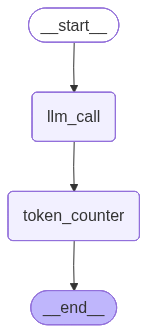

In [22]:
display(Image(app.get_graph().draw_mermaid_png()))

In [36]:
result = app.invoke({
    "message": [HumanMessage(content="Hi, this is Suman. whats your name")]
})

In [37]:
result

{'message': [HumanMessage(content='Hi, this is Suman. whats your name', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hi Suman! I'm Qwen, a large language model developed by Tongyi Lab. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_tokens': 22, 'total_tokens': 160, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 147, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'stepfun/step-3.5-flash:free', 'system_fingerprint': None, 'id': 'gen-1772389221-R7sKxSBquLs3sp6uNPuK', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019caaa1-3cfd-7a91-887f-2d560372b719-0', tool_calls=

In [38]:
for m in result["message"]:
    print(type(m).__name__,":",m.content)

HumanMessage : Hi, this is Suman. whats your name
AIMessage : Hi Suman! I'm Qwen, a large language model developed by Tongyi Lab. How can I assist you today?
AIMessage : Total token number in the generated answer (word count) is 18


In [41]:
llm_chat

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000015AE483E9F0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000015AE483D160>, root_client=<openai.OpenAI object at 0x0000015AE433CEC0>, root_async_client=<openai.AsyncOpenAI object at 0x0000015AE483D280>, model_name='stepfun/step-3.5-flash:free', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1')

In [46]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
import wikipedia

In [45]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500,wiki_client=wikipedia)

In [47]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [48]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [69]:
import os
load_dotenv()
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [70]:
TAVILY_API_KEY

'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'

In [71]:
# make sure we actually have a key before instantiating the tool
if not TAVILY_API_KEY:
    # you can set it here for testing, or raise so you notice the problem
    # os.environ["TAVILY_API_KEY"] = "your‑real‑key‑here"
    raise RuntimeError(
        "TAVILY_API_KEY is not set. "
        "Add it to your environment (e.g. in .env) or assign it explicitly."
    )

tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [72]:
tool.invoke({"query":"how is the job for fresher graduate in 2026"})

[{'title': 'Hiring Flat for the College Class of 2026',
  'url': 'https://www.naceweb.org/job-market/trends-and-predictions/hiring-flat-for-the-college-class-of-2026',
  'content': 'Reflecting an uncertain job market for college graduates, employers are projecting just a 1.6% increase in hiring for the Class of 2026 when compared to the Class of 2025, according to results of NACE’s Job Outlook 2026 survey.\n\nThat flat hiring projection is consistent with the tight labor market employers reported at the end of the 2024-25 recruiting year. (See Figure 1.)\n\nThese findings are also consistent with what NACE is seeing with general employment indicators at large. NACE found that employers are less positive about the overall job market for upcoming graduates this year than they were in last several years. Currently, a plurality of employers rate the overall job market for new graduates as "fair," compared to a year ago, when they characterized it as "good." (See Figure 2.) [...] Additional

In [73]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [74]:
search.invoke("what is the latest update on iphone17 releasr?")

Impersonate 'firefox_109' does not exist, using 'random'


"Oct 1, 2025 · Along with the new iPhone 17 models, Apple in September released the new-generation Apple Watch Series 11 and Apple Watch Ultra 3, as well as new AirPods Pro 3. We covered the Apple event below, and you can read our minute-by-minute account below of all of the company's announcements, along with updates as we get some hands-on time with the new phones... Apple has officially announced the iPhone 17 lineup with iOS 26 out of the box. The new update brings a redesigned UI, dubbed Liquid Glass. Several first-party apps like Photos, Messages,... Sep 17 , 2025 · The iPhone 17 lineup has officially arrived, bringing with it Apple’s most advanced hardware yet and the debut of iOS 26. Whether you’re eyeing the sleek iPhone 17 , the powerhouse iPhone 17 Pro, or you just want to know what’s new in iOS 26, this guide covers everything you need to know. From release dates and pricing to colors, cases, camera upgrades, and early reviews, we break down ... Sep 10, 2025 · Explore all t

In [ ]:
# bingsearch, googlesearchapi

In [76]:
from langchain_community.tools import YouTubeSearchTool

In [78]:
tool=YouTubeSearchTool()

In [79]:
tool.name

'youtube_search'

In [80]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [81]:
tool.invoke("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=fQw1_U22URk&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [82]:
tool.invoke("codewithharry")

"['https://www.youtube.com/watch?v=UrsmFxEIp5k&pp=ygUNY29kZXdpdGhoYXJyeQ%3D%3D', 'https://www.youtube.com/watch?v=2jmiNO3jwrA&pp=ygUNY29kZXdpdGhoYXJyeQ%3D%3D']"

In [83]:
tool.run("codewithharry")

"['https://www.youtube.com/watch?v=UrsmFxEIp5k&pp=ygUNY29kZXdpdGhoYXJyeQ%3D%3D', 'https://www.youtube.com/watch?v=2jmiNO3jwrA&pp=ygUNY29kZXdpdGhoYXJyeQ%3D%3D']"

In [84]:
# custom tool

In [85]:
def multiply(a:int,b:int)->int:
    return a*b

In [86]:
multiply(10,20)

200

In [87]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [88]:
from langchain.tools import tool

with out description can not create a tool

In [90]:
@tool
def multiply(a:int,b:int)->int:
    '''this tool si for multiplication'''
    return a*b

In [93]:
multiply.invoke({"a":10,"b":20})

200

In [95]:
multiply.name

'multiply'

In [96]:
multiply.description

'this tool si for multiplication'

In [97]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [99]:
@tool
def get_word_len(word:str)->int:
    '''length of the string'''
    return len(word)

description is the metadata

In [100]:
get_word_len.name

'get_word_len'

In [101]:
get_word_len.description

'length of the string'

In [102]:
get_word_len.invoke("Hello world")

11

In [103]:
@tool
def call_gmail_api(args):
    '''this is a tool to call gmail api'''
    pass

In [105]:
@tool
def call_sqlite_db(args):
    '''this is a tool to call sqlite db'''
    pass

In [107]:
get_word_len.invoke({"word":"heloo world"})

11

In [109]:
import yfinance as yf

In [117]:
@tool
def get_stock_price(ticker:str)->str:
    '''this is a tool to get stock price using yfinance'''
    try:
        stock=yf.Ticker(ticker)
        # get last 1 day historical data
        data=stock.history(period="1d")
        
        if data.empty:
            return f"No data found for ticker '{ticker}'.Please check"
        # latest close price of the stock
        latest_close=data["Close"].iloc[-1]
        
        #Detect ccurrency
        currency=stock.info.get("currency","")
        symbol_map={
            "INR":"₹",
            "USD":"$",
            "EUR":"€",
            "GBP":"£"
        }
        symbol=symbol_map.get(currency,"")
        currency_text=currency if currency else ""
        
        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price is {ticker.upper()} was {latest_close:.2f} {currency_text}."
        
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [118]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2613.50.'

In [119]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $265.26.'

In [120]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $401.17.'

In [122]:
get_stock_price.invoke("HDFCBANK.Ns")

'The last closing price of HDFCBANK.NS was ₹879.40.'

In [123]:
[get_stock_price,get_word_len,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000015AFEAE8AE0>),
 StructuredTool(name='get_word_len', description='length of the string', args_schema=<class 'langchain_core.utils.pydantic.get_word_len'>, func=<function get_word_len at 0x0000015AE85A3920>),
 StructuredTool(name='multiply', description='this tool si for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000015AE799D440>)]

In [148]:
tool=[get_stock_price,get_word_len,multiply,wiki_tool]

In [149]:
llm_with_tools=llm_chat.bind_tools(tool)

In [150]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000015AE483E9F0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000015AE483D160>, root_client=<openai.OpenAI object at 0x0000015AE433CEC0>, root_async_client=<openai.AsyncOpenAI object at 0x0000015AE483D280>, model_name='stepfun/step-3.5-flash:free', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_stock_price', 'description': 'this is a tool to get stock price using yfinance', 'parameters': {'properties': {'ticker': {'type': 'string'}}, 'required': ['ticker'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_word_len', 'description': 'length of the string', 'parameters': {'properties': {'word': {'type': 'string'}}, 'required': ['word'], 'type': 'object'}}}, {'type': 'function', 'fu

In [151]:
result=llm_with_tools.invoke("what is the stock price of TCS.NS")

In [152]:
# import google.generativeai as genai

# # Use your key from AI Studio
# genai.configure(api_key="YOUR_FREE_API_KEY")

# # Choose a free-tier model (e.g., gemini-2.5-flash)
# model = genai.GenerativeModel('gemini-2.5-flash')

# response = model.generate_content("Explain the difference between a View and a Materialized View in Oracle SQL.")
# print(response.text)

In [153]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 464, 'total_tokens': 558, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 65, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'stepfun/step-3.5-flash:free', 'system_fingerprint': None, 'id': 'gen-1772478298-Jzlae0ETAghvHmP1b4V9', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019caff0-7916-7c00-93d7-e404c922ac22-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'call_69911721d0194e11ae3aac1d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 464, 'output_tokens': 94, 'total_

In [154]:
result.content

''

In [155]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_69911721d0194e11ae3aac1d',
  'type': 'tool_call'}]

In [156]:
result=llm_with_tools.invoke("How many words are there in the sentence 'hello world")

In [157]:
result.tool_calls

[]

In [158]:
result=llm_with_tools.invoke("How we multiply 10 and 20")

In [159]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'call_25e75ea3498949d7b3fd1ef7',
  'type': 'tool_call'}]

In [160]:
result.content

''

In [161]:
result=llm_with_tools.invoke("hello, how are you>")

In [162]:
result

AIMessage(content="Hello! I'm doing well, thank you for asking. I'm here to help you with any questions or tasks you need assistance with. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 460, 'total_tokens': 534, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 44, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'stepfun/step-3.5-flash:free', 'system_fingerprint': None, 'id': 'gen-1772478355-EoZTvLUPpuln8mb2DbAL', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019caff1-58c8-7970-a148-c17c3c6aad75-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 460, 'out

In [163]:
result.content

"Hello! I'm doing well, thank you for asking. I'm here to help you with any questions or tasks you need assistance with. How can I assist you today?"

whatever question to be asked is not reelated to tool, llm will try to answer for that.

if the question realted to the tool, llm will say-> do one thing -> configure the tool, aske the correct answer to the tool only.

In [164]:
result.tool_calls

[]

In [165]:
result=llm_with_tools.invoke("what was in the latest indian union budge report of 2026?")

In [166]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 340, 'prompt_tokens': 470, 'total_tokens': 810, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 328, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'stepfun/step-3.5-flash:free', 'system_fingerprint': None, 'id': 'gen-1772478376-rM87krSi3skHmy3TbkGX', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019caff1-a44c-7af2-b3d7-4dffc195e752-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Indian Union budget 2026'}, 'id': 'call_ed97f6a2a5194f44b6196256', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 470, 'output_tokens'

In [167]:
result.content

''

In [168]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union budget 2026'},
  'id': 'call_ed97f6a2a5194f44b6196256',
  'type': 'tool_call'}]

In [183]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [184]:
SYSTEM_PROMPT=SystemMessage(content="You are a helpful assistant that can use tools to answer questions")

In [185]:
def function_1(state:MessagesState):
    # question will come
    user_question=state["messages"] 
    # going to attatch with system prompt
    input_question=[SYSTEM_PROMPT] + user_question
    # passing to llm with tool
    response=llm_with_tools.invoke(input_question)
    # return the response
    return {"messages":[response]}

In [186]:
tool

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000015AFEAE8AE0>),
 StructuredTool(name='get_word_len', description='length of the string', args_schema=<class 'langchain_core.utils.pydantic.get_word_len'>, func=<function get_word_len at 0x0000015AE85A3920>),
 StructuredTool(name='multiply', description='this tool si for multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000015AE799D440>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\AgenticAI\\venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [187]:
function_2=ToolNode(tools=tool)

In [188]:
workflow=StateGraph(MessagesState)

In [189]:
workflow.add_node("llm",function_1)

In [190]:
workflow.add_node("tools", function_2)

In [191]:
workflow.add_edge(START,"llm")

In [192]:
workflow.add_conditional_edges(
    "llm",
    tools_condition
)

In [193]:
workflow.add_edge('tools',"llm")

In [194]:
app=workflow.compile()

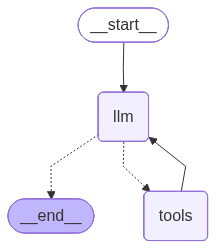

In [195]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

this is call resoning & action workflow
this is one of the Agentic pattern